<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">ANALYSE DU STOCK ET DES VENTES DU SITE BOTTLENECK</h1>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner code, texte et graphiques.

Cet outil est formidable pour plusieurs raisons:

+ Il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'une instruction, de la corriger si nécessaire.
+ Il permet aussi de rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ Il est possible d'ajouter des graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandé.

Et gardez à l'esprit qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >


<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.1 - Importation des librairies et paramétrage</h3>
</div>

In [1]:
#Importation de la librairie Pandas
import pandas as pd

In [2]:
#Importation de la librairie NumPy
import numpy as np

In [3]:
#Importation de la librairie Matplotlib
import matplotlib.pyplot as plt

In [4]:
#Importation de la librairie Seaborn
import seaborn as sns

In [5]:
#Afficher toutes les colonnes d'un dataframe et monter le maximum de lignes affichées à 100
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.2 - Chargements des fichiers</h3>
</div>

In [6]:
#Connecter au Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
#Importation du fichier web.xlsx
df_web = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/Data P6/web.xlsx')

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [8]:
#Importation du fichier erp.xlsx
df_erp = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/Data P6/erp.xlsx')

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [9]:
#Importation du fichier liaison.xlsx
df_liaison = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/Data P6/liaison.xlsx')

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >


<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Analyse exploratoire du fichier erp.xlsx</h3>
</div>

In [10]:
#Consulter les dimensions du dataset et les caractéristiques des colonnes (nombre, nature, taille...)
df_erp.info()
df_erp.describe(include = 'all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      825 non-null    int64  
 1   onsale_web      825 non-null    int64  
 2   price           825 non-null    float64
 3   stock_quantity  825 non-null    int64  
 4   stock_status    825 non-null    object 
 5   purchase_price  825 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 38.8+ KB


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
count,825.000000,825.000000,825.000000,825.000000,825,825.000000
unique,NaN,NaN,NaN,NaN,2,NaN
top,NaN,NaN,NaN,NaN,instock,NaN
freq,NaN,NaN,NaN,NaN,733,NaN
mean,5162.597576,0.867879,32.187697,21.589091,NaN,16.940582
std,902.644635,0.338828,26.712077,21.933807,NaN,14.561840
min,3847.000000,0.000000,-20.000000,-10.000000,NaN,2.740000
25%,4348.000000,1.000000,14.500000,7.000000,NaN,7.590000
50%,4907.000000,1.000000,24.300000,18.000000,NaN,12.710000
75%,5805.000000,1.000000,42.000000,30.000000,NaN,22.020000


In [11]:
#Afficher les 5 premières lignes de la table
df_erp.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,outofstock,23.77


In [12]:
#Vérifier si il y a des lignes en doublon dans la colonne product_id
print("Il y a {} doublon(s) dans la colonne product_id.".format(df_erp.duplicated(subset=['product_id']).sum()))

Il y a 0 doublon(s) dans la colonne product_id.


<div style="border: 1px solid RGB(51,165,182);" >



<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1 - Vérification du stock</h3>
</div>

In [13]:
#Afficher les valeurs distinctes de la colonne stock_status
df_erp['stock_status'].value_counts()

,count
stock_status,
instock,733
outofstock,92


In [14]:
#Création d'une colonne "stock_status_2" en lien avec la colonne "stock_quantity" (outofstock ou instock)
df_erp_stock_analyse = df_erp.copy()
df_erp_stock_analyse['stock_status_2'] = np.where(df_erp_stock_analyse['stock_quantity'] == 0, 'outofstock', 'instock')

In [15]:
#Comparer les colonnes "stock_status" et "stock_status_2" pour voir s'il y a des erreurs
erp_compare_stock = df_erp_stock_analyse["stock_status"] == df_erp_stock_analyse["stock_status_2"]
erp_compare_stock.value_counts()

,count
True,821
False,4


In [16]:
#Identifier les lignes où il y a une erreur sur le "stock_status"
df_erp_error_stock = df_erp_stock_analyse[(df_erp_stock_analyse["stock_status"] != df_erp_stock_analyse["stock_status_2"]) | (df_erp_stock_analyse["stock_quantity"] < 0)]
df_erp_error_stock

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
4,4039,1,46.0,3,outofstock,23.77,instock
398,4885,1,18.7,0,instock,9.66,outofstock
449,4973,0,10.0,-10,outofstock,4.96,instock
573,5700,1,44.5,-1,outofstock,22.30,instock


<div style="border: 1px solid RGB(51,165,182);" >


<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.2 - Vérification prix vente vs prix achat</h3>
</div>

In [17]:
#création de la colonne price - purchase_price
df_erp_price_analyse = df_erp.copy()
df_erp_price_analyse['price_compare'] = df_erp_price_analyse['price'] - df_erp_price_analyse['purchase_price']

In [18]:
#Vérifier que les valeurs calculées soient positives
erp_compare_price = df_erp_price_analyse["price_compare"] > 0
erp_compare_price.value_counts()

,count
price_compare,
True,818
False,7


In [19]:
#Identifier les lignes où il y a une erreur sur le prix
df_erp_error_price = df_erp_price_analyse[(df_erp_price_analyse["price_compare"] <= 0) | (df_erp_price_analyse["price"] <= 0) | (df_erp_price_analyse["purchase_price"] <= 0)]
df_erp_error_price

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,price_compare
151,4233,0,-20.00,0,outofstock,10.33,-30.33
210,4355,1,12.65,97,instock,77.48,-64.83
391,4864,0,8.30,0,outofstock,9.99,-1.69
469,5017,0,-8.00,0,outofstock,4.34,-12.34
724,6324,0,92.00,18,instock,99.00,-7.00
739,6594,0,-9.10,19,instock,4.61,-13.71
817,7196,0,31.00,55,instock,31.20,-0.20


<div style="border: 1px solid RGB(51,165,182);" >


<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.3 - Analyse de la variable ONSALE_WEB</h3>
</div>

In [20]:
#Vérification de la colonne onsale_web et des valeurs qu'elle contient.
df_erp['onsale_web'].value_counts()

,count
onsale_web,
1,716
0,109


<div style="border: 1px solid RGB(51,165,182);" >


<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.4 - Mise en forme du dataframe corrigé</h3>
</div>

In [21]:
#Corriger la ou les données incohérentes
df_erp_fix = df_erp.copy()
df_erp_fix.drop(df_erp_error_stock.index, inplace=True)
df_erp_fix.drop(df_erp_error_price.index, inplace=True)

#Suppression des colonnes redondantes ou inutiles
df_erp_fix.drop(['stock_status'], axis=1, inplace=True)

#Caractéristiques du nouveau dataframe
df_erp_fix.info()
df_erp_fix.describe(include = 'all')

<class 'pandas.core.frame.DataFrame'>
Index: 814 entries, 0 to 824
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      814 non-null    int64  
 1   onsale_web      814 non-null    int64  
 2   price           814 non-null    float64
 3   stock_quantity  814 non-null    int64  
 4   purchase_price  814 non-null    float64
dtypes: float64(2), int64(3)
memory usage: 38.2 KB


,product_id,onsale_web,price,stock_quantity,purchase_price
count,814.000000,814.000000,814.000000,814.000000,814.000000
mean,5160.888206,0.874693,32.344963,21.658477,16.803857
std,901.374111,0.331270,26.625313,21.786029,14.178394
min,3847.000000,0.000000,5.200000,0.000000,2.740000
25%,4339.750000,1.000000,14.625000,7.000000,7.597500
50%,4905.500000,1.000000,24.400000,18.000000,12.720000
75%,5804.750000,1.000000,41.950000,30.000000,22.010000
max,7338.000000,1.000000,225.000000,145.000000,137.810000


In [22]:
#Répartition de produits vendus en ligne
df_erp_fix['onsale_web'].value_counts()

,count
onsale_web,
1,712
0,102


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2 - Analyse exploratoire du fichier web.xlsx</h3>
</div>


In [23]:
#Consulter la dimension du dataset et les caractéristiques des colonnes (nombre, nature, taille...)
df_web.info()
df_web.describe(include = 'all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1513 entries, 0 to 1512
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   sku                    1428 non-null   object        
 1   virtual                1513 non-null   int64         
 2   downloadable           1513 non-null   int64         
 3   rating_count           1513 non-null   int64         
 4   average_rating         1430 non-null   float64       
 5   total_sales            1430 non-null   float64       
 6   tax_status             716 non-null    object        
 7   tax_class              0 non-null      float64       
 8   post_author            1430 non-null   float64       
 9   post_date              1430 non-null   datetime64[ns]
 10  post_date_gmt          1430 non-null   datetime64[ns]
 11  post_content           0 non-null      float64       
 12  product_type           1429 non-null   object        
 13  pos

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,post_date_gmt,post_content,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_password,post_name,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
count,1428.0,1513.0,1513.0,1513.0,1430.0,1430.000000,716,0.0,1430.000000,1430,1430,0.0,1429,1430,716,1430,1430,1430,0.0,1430,1430,1430,0.0,1430.0,1430,1430.0,1430,714,1430.0
unique,714.0,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,7,713,679,1,1,1,NaN,716,NaN,NaN,NaN,NaN,1430,NaN,2,1,NaN
top,14569.0,NaN,NaN,NaN,NaN,NaN,taxable,NaN,NaN,NaN,NaN,NaN,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,Les eaux de vie naissent d'une subtile alchimi...,publish,closed,closed,NaN,moulin-de-gassac-igp-pays-dherault-faune-2017,NaN,NaN,NaN,NaN,https://www.bottle-neck.fr/wp-content/uploads/...,NaN,product,image/jpeg,NaN
freq,2.0,NaN,NaN,NaN,NaN,NaN,716,NaN,NaN,NaN,NaN,NaN,1318,4,12,1430,1430,1430,NaN,2,NaN,NaN,NaN,NaN,1,NaN,716,714,NaN
mean,NaN,0.0,0.0,0.0,0.0,8.223077,NaN,NaN,1.998601,2018-08-22 03:22:17.090909184,2018-08-22 01:53:30.097902080,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-06-20 13:59:29.781818112,2020-06-20 12:06:02.509090816,NaN,0.0,NaN,0.0,NaN,NaN,0.0
min,NaN,0.0,0.0,0.0,0.0,-56.000000,NaN,NaN,1.000000,2018-02-08 12:58:52,2018-02-08 11:58:52,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-02-20 15:19:23,2018-02-20 14:19:23,NaN,0.0,NaN,0.0,NaN,NaN,0.0
25%,NaN,0.0,0.0,0.0,0.0,5.000000,NaN,NaN,2.000000,2018-02-27 20:01:12.500000,2018-02-27 19:01:12.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-06-18 10:45:05.249999872,2020-06-18 08:45:05.249999872,NaN,0.0,NaN,0.0,NaN,NaN,0.0
50%,NaN,0.0,0.0,0.0,0.0,8.000000,NaN,NaN,2.000000,2018-04-19 14:56:05,2018-04-19 12:56:05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-08-04 09:30:06,2020-08-04 07:30:06,NaN,0.0,NaN,0.0,NaN,NaN,0.0
75%,NaN,0.0,0.0,0.0,0.0,11.000000,NaN,NaN,2.000000,2019-01-31 14:35:47,2019-01-31 13:35:47,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-08-25 10:32:32,2020-08-25 08:32:32,NaN,0.0,NaN,0.0,NaN,NaN,0.0
max,NaN,0.0,0.0,0.0,0.0,122.000000,NaN,NaN,2.000000,2020-07-20 11:00:00,2020-07-20 09:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-08-27 18:55:03,2020-08-27 16:55:03,NaN,0.0,NaN,0.0,NaN,NaN,0.0


In [24]:
#Afficher les premières lignes du dataframe
df_web.head()

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,post_date_gmt,post_content,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_password,post_name,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
0,11862,0,0,0,0.0,3.0,NaN,NaN,2.0,2018-02-12 13:46:23,2018-02-12 12:46:23,NaN,Vin,Gilles Robin Hermitage Rouge 2012,NaN,publish,closed,closed,NaN,gilles-robin-hermitage-2012,2019-01-31 12:12:56,2019-01-31 11:12:56,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
1,16057,0,0,0,0.0,5.0,NaN,NaN,2.0,2018-04-17 15:29:17,2018-04-17 13:29:17,NaN,Vin,Domaine Pellé Sancerre Rouge La Croix Au Garde...,NaN,publish,closed,closed,NaN,pelle-sancerre-rouge-la-croix-au-garde-2017,2020-07-07 10:05:02,2020-07-07 08:05:02,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
2,14692,0,0,0,0.0,5.0,taxable,NaN,2.0,2019-03-19 10:06:47,2019-03-19 09:06:47,NaN,Vin,Château Fonréaud Bordeaux Blanc Le Cygne 2016,<div>Grâce à la complémentarité des 3 cépages ...,publish,closed,closed,NaN,fonreaud-bordeaux-blanc-le-cygne-2016,2020-04-25 21:40:31,2020-04-25 19:40:31,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
3,16295,0,0,0,0.0,14.0,NaN,NaN,2.0,2018-02-15 14:05:06,2018-02-15 13:05:06,NaN,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Ro...,NaN,publish,closed,closed,NaN,moulin-de-gassac-igp-pays-dherault-guilhem-ros...,2020-08-27 18:55:03,2020-08-27 16:55:03,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
4,15328,0,0,0,0.0,2.0,taxable,NaN,2.0,2019-03-27 18:05:09,2019-03-27 17:05:09,NaN,Vin,Agnès Levet Côte Rôtie Maestria 2017,"<span style=""float: none; background-color: tr...",publish,closed,closed,NaN,agnes-levet-cote-rotie-maestria-2017,2020-07-25 15:45:02,2020-07-25 13:45:02,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0


In [25]:
#Observation de la colonne 'post_type'
df_web['post_type'].value_counts()

,count
post_type,
product,716
attachment,714


In [26]:
#Identifier les lignes des pièces-jointes créant des doublons de sku
index_web_rows_suppr = df_web.loc[df_web['post_type']=='attachment'].index

In [27]:
#Identifier les colonnes à supprimer (vides, redondantes, surinformation...)
index_web_columns_suppr = df_web[['virtual','downloadable','rating_count','average_rating','tax_status','tax_class','post_author','post_date','post_date_gmt','post_content','post_excerpt','post_status','comment_status','ping_status','post_password','post_name','post_modified','post_modified_gmt','post_content_filtered','post_parent','guid','menu_order','post_type','post_mime_type','comment_count']]

In [28]:
#Identifier les lignes sans sku
df_web_no_sku = df_web[df_web["sku"].isnull()]
df_web_no_sku.info()

<class 'pandas.core.frame.DataFrame'>
Index: 85 entries, 8 to 1457
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   sku                    0 non-null      object        
 1   virtual                85 non-null     int64         
 2   downloadable           85 non-null     int64         
 3   rating_count           85 non-null     int64         
 4   average_rating         2 non-null      float64       
 5   total_sales            2 non-null      float64       
 6   tax_status             2 non-null      object        
 7   tax_class              0 non-null      float64       
 8   post_author            2 non-null      float64       
 9   post_date              2 non-null      datetime64[ns]
 10  post_date_gmt          2 non-null      datetime64[ns]
 11  post_content           0 non-null      float64       
 12  product_type           2 non-null      object        
 13  post_title

In [29]:
#Supprimer les colonnes et les lignes identifiées précédemment
df_web_analyse = df_web.copy()
df_web_analyse.drop(index_web_rows_suppr, axis=0, inplace=True)
df_web_analyse.drop(index_web_columns_suppr, axis=1, inplace=True)
df_web_analyse.drop(df_web_no_sku.index, inplace=True)

In [30]:
#Caractéristiques du dataframe modifié
df_web_analyse.info()
df_web_analyse.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
Index: 714 entries, 2 to 1509
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sku           714 non-null    object 
 1   total_sales   714 non-null    float64
 2   product_type  713 non-null    object 
 3   post_title    714 non-null    object 
dtypes: float64(1), object(3)
memory usage: 27.9+ KB


,sku,total_sales,product_type,post_title
count,714.0,714.000000,713,714
unique,714.0,NaN,6,711
top,15662.0,NaN,Vin,Marc Colin Et Fils Chassagne-Montrachet Blanc ...
freq,1.0,NaN,658,2
mean,NaN,8.054622,NaN,NaN
std,NaN,4.161344,NaN,NaN
min,NaN,0.000000,NaN,NaN
25%,NaN,5.000000,NaN,NaN
50%,NaN,8.000000,NaN,NaN
75%,NaN,11.000000,NaN,NaN


In [31]:
#Vérification des 'sku' en doublon
print("Il y a {} doublon(s) dans la colonne sku.".format(df_web_analyse.duplicated(subset=['sku']).sum()))

Il y a 0 doublon(s) dans la colonne sku.


In [32]:
#Valeurs de la colonne 'sku' ne respectant pas la numérotation générale
web_sku_cleaned = df_web_analyse["sku"].fillna('')
web_numeric = web_sku_cleaned.str.isnumeric()
web_numeric = web_numeric.astype(bool)
web_no_numeric = df_web_analyse[~web_numeric].dropna(subset=['sku'])
web_no_numeric

,sku,total_sales,product_type,post_title
272,13127-1,4.0,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007
1387,bon-cadeau-25-euros,7.0,NaN,Bon cadeau de 25€


In [33]:
#Suppression du 'bon-cadeau-25-euros' source d'erreur car il sera utilisé pour acheter d'autres produits
df_web_analyse.drop(df_web_analyse[df_web_analyse['sku'] == 'bon-cadeau-25-euros'].index, inplace=True)

In [34]:
#Analyse du 'sku' '13127-1' et cohérence avec le reste
df_web_analyse[(df_web_analyse ["sku"] == 13127) | (df_web_analyse["sku"] == '13127-1')]

,sku,total_sales,product_type,post_title
123,13127,5.0,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2012
272,13127-1,4.0,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007


In [35]:
#Uniformisation du type de 'sku' pour pouvoir trier, grouper...
df_web_analyse['sku'] = df_web_analyse['sku'].astype(str)
df_web_analyse.info()

<class 'pandas.core.frame.DataFrame'>
Index: 713 entries, 2 to 1509
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sku           713 non-null    object 
 1   total_sales   713 non-null    float64
 2   product_type  713 non-null    object 
 3   post_title    713 non-null    object 
dtypes: float64(1), object(3)
memory usage: 27.9+ KB


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3 - Analyse exploratoire du fichier liaison.xlsx</h3>
</div>

In [36]:
#Consulter la taille du dataframe et les caractéristiques des colonnes (nombre, nature, taille...)
df_liaison.info()
df_liaison.describe(include = 'all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_web      734 non-null    object
 1   product_id  825 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 13.0+ KB


,id_web,product_id
count,734.0,825.000000
unique,734.0,NaN
top,16230.0,NaN
freq,1.0,NaN
mean,NaN,5162.597576
std,NaN,902.644635
min,NaN,3847.000000
25%,NaN,4348.000000
50%,NaN,4907.000000
75%,NaN,5805.000000


In [37]:
#Vérifier le caractère unique de "product_id"
print("Il y a {} doublon(s) dans la colonne product_id.".format(df_liaison.duplicated(subset=['product_id']).sum()))

Il y a 0 doublon(s) dans la colonne product_id.


In [38]:
#Vérifier s'il y a des articles sans correspondance
erp_verif_corresp = df_liaison['id_web'].notnull()
erp_verif_corresp.value_counts()

,count
id_web,
True,734
False,91


In [39]:
#Identifier les lignes 'id_web' vides
df_liaison_no_id_web = df_liaison[df_liaison["id_web"].isnull()]
df_liaison_no_id_web.info()

<class 'pandas.core.frame.DataFrame'>
Index: 91 entries, 19 to 821
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_web      0 non-null      object
 1   product_id  91 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 2.1+ KB


In [40]:
#Supprimer les lignes correspondant à des id_web vides
df_liaison_analyse = df_liaison.copy()
df_liaison_analyse.drop(df_liaison_no_id_web.index, axis=0, inplace=True)
df_liaison_analyse['id_web'] = df_liaison_analyse['id_web'].astype(str)
df_liaison_analyse.info()

<class 'pandas.core.frame.DataFrame'>
Index: 734 entries, 0 to 824
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_web      734 non-null    object
 1   product_id  734 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 17.2+ KB


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Jonction des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.1 - Jonction du fichier df_erp et df_liaison</h3>
</div>

In [41]:
#Fusion des fichiers df_erp et df_liaison
df_merge = pd.merge(df_erp_fix, df_liaison_analyse, on='product_id', how='left')
df_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 814 entries, 0 to 813
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      814 non-null    int64  
 1   onsale_web      814 non-null    int64  
 2   price           814 non-null    float64
 3   stock_quantity  814 non-null    int64  
 4   purchase_price  814 non-null    float64
 5   id_web          729 non-null    object 
dtypes: float64(2), int64(3), object(1)
memory usage: 38.3+ KB


In [42]:
#Identification des 'product_id' présent dans la table de liaison mais absent de l'ERP
df_full_merge = pd.merge(df_erp_fix, df_liaison_analyse, on='product_id', how='outer', indicator=True)
df_erreurs = df_full_merge[df_full_merge['_merge'].isin(['right_only'])]
df_erreurs

,product_id,onsale_web,price,stock_quantity,purchase_price,id_web,_merge
4,4039,NaN,NaN,NaN,NaN,19815,right_only
209,4355,NaN,NaN,NaN,NaN,12589,right_only
390,4864,NaN,NaN,NaN,NaN,15154,right_only
397,4885,NaN,NaN,NaN,NaN,14981,right_only
570,5700,NaN,NaN,NaN,NaN,14736,right_only


In [43]:
#Suppression des lignes identifiées
df_merge.drop(df_erreurs.index, axis=0, inplace=True)
df_merge.info()

<class 'pandas.core.frame.DataFrame'>
Index: 809 entries, 0 to 813
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      809 non-null    int64  
 1   onsale_web      809 non-null    int64  
 2   price           809 non-null    float64
 3   stock_quantity  809 non-null    int64  
 4   purchase_price  809 non-null    float64
 5   id_web          724 non-null    object 
dtypes: float64(2), int64(3), object(1)
memory usage: 44.2+ KB


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.2 - Jonction du fichier df_merge et df_web</h3>
</div>

In [44]:
#Fusionner les datasets df_merge et df_web
df_merge_final = pd.merge(df_merge, df_web_analyse, left_on='id_web', right_on='sku', how='left')
df_merge_final.reset_index(drop=True)
df_merge_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 809 entries, 0 to 808
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      809 non-null    int64  
 1   onsale_web      809 non-null    int64  
 2   price           809 non-null    float64
 3   stock_quantity  809 non-null    int64  
 4   purchase_price  809 non-null    float64
 5   id_web          724 non-null    object 
 6   sku             705 non-null    object 
 7   total_sales     705 non-null    float64
 8   product_type    705 non-null    object 
 9   post_title      705 non-null    object 
dtypes: float64(3), int64(3), object(4)
memory usage: 63.3+ KB


In [45]:
#Vérification si tous les produits présents sur l'extraction des ventes web sont bien identifiés comme vendus en ligne sur l'ERP
df_merge_final.loc[(df_merge_final['sku'].notna()) & (df_merge_final['onsale_web']==0)]

,product_id,onsale_web,price,stock_quantity,purchase_price,id_web,sku,total_sales,product_type,post_title
121,4200,0,5.8,33,3.12,16295,16295,14.0,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Ro...


In [46]:
#Correction des lignes incohérentes
df_merge_final.loc[df_merge_final['product_id'] == 4200, 'onsale_web'] = 1
df_merge_final.loc[df_merge_final['product_id'] == 4200]

,product_id,onsale_web,price,stock_quantity,purchase_price,id_web,sku,total_sales,product_type,post_title
121,4200,1,5.8,33,3.12,16295,16295,14.0,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Ro...


In [47]:
#Vérification de la présence du produit bon-cadeau-25-euros dans le dataframe
df_merge_bon_cadeau=df_merge_final.loc[df_merge_final['id_web'] == 'bon-cadeau-25-euros']
df_merge_bon_cadeau

,product_id,onsale_web,price,stock_quantity,purchase_price,id_web,sku,total_sales,product_type,post_title
434,4954,1,25.0,23,13.3,bon-cadeau-25-euros,NaN,NaN,NaN,NaN


In [48]:
#Identification des produits inactifs (0 stock et 0 vente)
df_product_inactive=df_merge_final.loc[(df_merge_final['stock_quantity']==0) & ((df_merge_final['total_sales']==0)|(df_merge_final['total_sales'].isnull()))]

In [49]:
#Affichage des premières lignes de produits inactifs
df_product_inactive.head(20)

,product_id,onsale_web,price,stock_quantity,purchase_price,id_web,sku,total_sales,product_type,post_title
2,3850,1,20.8,0,10.64,15300,15300,0.0,Vin,Pierre Jean Villa Crozes-Hermitage Accroche Co...
6,4043,1,60.0,0,29.45,14980,14980,0.0,Vin,Pierre Gaillard Côte Rôtie Esprit de Blonde 2017
9,4047,1,18.3,0,9.93,14977,14977,0.0,Vin,Pierre Gaillard Côtes-du-Rhône Blanc Les Gendr...
13,4051,1,7.7,0,4.14,16045,16045,0.0,Vin,Jeanne Gaillard IGP Collines Rhodaniennes Syra...
14,4052,1,33.7,0,18.11,16030,16030,0.0,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape Blanc ...
17,4055,0,86.1,0,37.88,NaN,NaN,NaN,NaN,NaN
26,4065,1,19.5,0,9.67,15022,15022,0.0,Vin,Oratoire Saint Martin Cairanne Rouge Les Douye...
40,4079,1,37.0,0,19.50,13078,13078,0.0,Vin,Le Vieux Donjon Châteauneuf-du-Pape 2013
47,4090,0,73.0,0,33.79,NaN,NaN,NaN,NaN,NaN
48,4092,0,47.0,0,25.25,NaN,NaN,NaN,NaN,NaN


In [50]:
#Nettoyage du dataframe
df_merge_final.drop(df_product_inactive.index, axis=0, inplace=True)
df_merge_final.drop(df_merge_bon_cadeau.index, axis=0, inplace=True)
df_merge_final.drop(['sku','onsale_web'], axis=1, inplace=True)

In [51]:
#Caractéristiques du dataframe
df_merge_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 745 entries, 0 to 808
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      745 non-null    int64  
 1   price           745 non-null    float64
 2   stock_quantity  745 non-null    int64  
 3   purchase_price  745 non-null    float64
 4   id_web          686 non-null    object 
 5   total_sales     684 non-null    float64
 6   product_type    684 non-null    object 
 7   post_title      684 non-null    object 
dtypes: float64(3), int64(2), object(3)
memory usage: 52.4+ KB


In [52]:
#Affichage premières lignes du dataframe
df_merge_final.head()

,product_id,price,stock_quantity,purchase_price,id_web,total_sales,product_type,post_title
0,3847,24.2,16,12.88,15298,6.0,Vin,Pierre Jean Villa Saint-Joseph Préface 2018
1,3849,34.3,10,17.54,15296,9.0,Vin,Pierre Jean Villa Saint-Joseph Rouge Tildé 2017
3,4032,14.1,26,6.92,19814,12.0,Vin,Pierre Jean Villa IGP Collines Rhodaniennes Ga...
4,4041,32.7,12,17.57,14975,6.0,Vin,Pierre Gaillard Condrieu 2018
5,4042,31.2,15,15.48,16042,8.0,Vin,Pierre Gaillard Cornas 2017


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Analyse univariée des prix</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.1 - Exploration par la visualisation de données</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.1.1 - Répartition des prix de vente</h3>
</div>

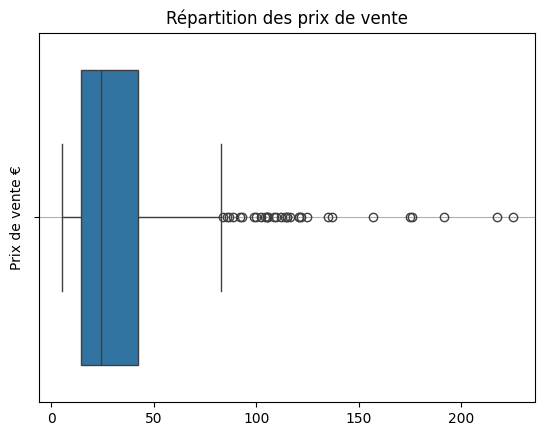

In [53]:
#Répartition des prix (boîte à moustache)
sns.boxplot(data=df_merge_final ,x='price')
plt.grid(axis='y')
plt.title('Répartition des prix de vente')
plt.ylabel('Prix de vente €')
plt.xlabel('')
plt.show()

In [54]:
#Mesures de dispersion de 'price'
df_merge_final['price'].describe()

,price
count,745.000000
mean,32.444430
std,26.948579
min,5.200000
25%,14.500000
50%,24.400000
75%,42.100000
max,225.000000


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.1.2 - Répartition des prix de vente par produit</h3>
</div>

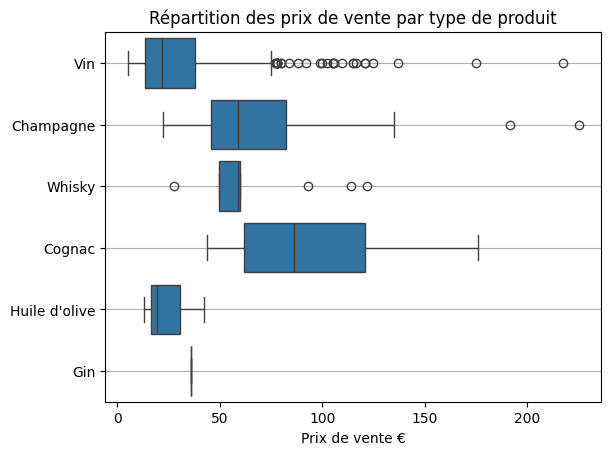

In [55]:
#Répartition des prix par produit (boîte à moustache)
sns.boxplot(data=df_merge_final,x='price', y='product_type')
plt.grid(axis='y')
plt.title('Répartition des prix de vente par type de produit')
plt.ylabel('')
plt.xlabel('Prix de vente €')
plt.show()

In [56]:
#Mesures de dispersion de 'price' par 'product_type'
df_merge_final.groupby('product_type')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
product_type,,,,,,,,
Champagne,26.0,72.996154,47.645193,22.5,46.00,59.00,82.125,225.0
Cognac,8.0,97.500000,48.153208,44.0,61.85,86.05,120.625,176.0
Gin,2.0,36.000000,0.000000,36.0,36.00,36.00,36.000,36.0
Huile d'olive,3.0,24.933333,15.291937,13.1,16.30,19.50,30.850,42.2
Vin,632.0,29.235443,23.702588,5.2,13.50,21.75,38.100,217.5
Whisky,13.0,65.830769,27.103302,27.5,49.50,59.00,59.800,122.0


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2 - Exploration par l'utilisation de méthodes statistiques</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.1 - Identification par le Z-index</h3>
</div>

In [57]:
#Calculer la moyenne du prix
moyenne_prix = df_merge_final['price'].mean()
print('Prix moyen : {} €'.format(round(moyenne_prix,2)))
#Calculer l'écart-type du prix
ecart_type_prix = df_merge_final['price'].std()
print('Ecart-type : {}'.format(round(ecart_type_prix,2)))
#Calculer le Z-score
z_score_prix = (df_merge_final['price'] - moyenne_prix) / ecart_type_prix
print('\nZ-score :\n{}'.format(round(z_score_prix,2)))

Prix moyen : 32.44 €
Ecart-type : 26.95

Z-score :
0     -0.31
1      0.07
3     -0.68
4      0.01
5     -0.05
       ... 
804    0.47
805    0.47
806    0.83
807   -0.22
808   -0.60
Name: price, Length: 745, dtype: float64


In [58]:
#Quel est le seuil prix dont le z-score est supérieur à 3?
seuil_prix_3 = moyenne_prix + (3 * ecart_type_prix)
print(round(seuil_prix_3,2))

113.29


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.2 - Identification par l'intervalle interquartile</h3>
</div>

In [59]:
#Définir un seuil pour les articles "outliers" en prix
IQR= df_merge_final['price'].quantile(0.75) - df_merge_final['price'].quantile(0.25)
seuil_prix_max = df_merge_final['price'].quantile(0.75) + (1.5 * IQR)
seuil_prix_min = df_merge_final['price'].quantile(0.25) - (1.5 * IQR)
print('Prix max :', round(seuil_prix_max,2))
print('Prix min :', round(seuil_prix_min,2))

Prix max : 83.5
Prix min : -26.9


In [60]:
#Définir le catalogue "outliers"
df_outliers=df_merge_final.loc[(df_merge_final['price'] > seuil_prix_max) | (df_merge_final['price'] < seuil_prix_min)].copy()
print('Total outliers :', df_outliers.shape[0])

Total outliers : 32


In [61]:
#Analyse des produits concernés
df_outliers.groupby('product_type')[['stock_quantity', 'total_sales']].sum()

,stock_quantity,total_sales
product_type,,
Champagne,585,44.0
Cognac,54,16.0
Vin,228,65.0
Whisky,25,7.0


In [62]:
#Analyse du taux de marge de ces produits
df_outliers['margin_rate'] = (df_outliers['price']-df_outliers['purchase_price']) / df_outliers['purchase_price']*100
df_outliers.groupby('product_type')['margin_rate'].mean()

,margin_rate
product_type,
Champagne,66.234328
Cognac,120.654513
Vin,94.507130
Whisky,124.264805


In [63]:
#Comparaison avec les taux de marge des autres produits
df_no_outliers=df_merge_final.drop(df_outliers.index).copy()

df_no_outliers['margin_rate'] = (df_no_outliers['price']-df_no_outliers['purchase_price']) / df_no_outliers['purchase_price']*100

marge_champagne_outliers = df_outliers.loc[df_outliers['product_type'] == 'Champagne']['margin_rate'].mean()
marge_champagne_no_outliers = df_no_outliers.loc[df_no_outliers['product_type'] == 'Champagne']['margin_rate'].mean()
difference_champagne = round(marge_champagne_outliers - marge_champagne_no_outliers, 2)

marge_cognac_outliers = df_outliers.loc[df_outliers['product_type'] == 'Cognac']['margin_rate'].mean()
marge_cognac_no_outliers = df_no_outliers.loc[df_no_outliers['product_type'] == 'Cognac']['margin_rate'].mean()
difference_cognac = round(marge_cognac_outliers - marge_cognac_no_outliers, 2)

marge_vin_outliers = df_outliers.loc[df_outliers['product_type'] == 'Vin']['margin_rate'].mean()
marge_vin_no_outliers = df_no_outliers.loc[df_no_outliers['product_type'] == 'Vin']['margin_rate'].mean()
difference_vin = round(marge_vin_outliers - marge_vin_no_outliers, 2)

marge_whisky_outliers = df_outliers.loc[df_outliers['product_type'] == 'Whisky']['margin_rate'].mean()
marge_whisky_no_outliers = df_no_outliers.loc[df_no_outliers['product_type'] == 'Whisky']['margin_rate'].mean()
difference_whisky = round(marge_whisky_outliers - marge_whisky_no_outliers, 2)

df_no_outliers.groupby('product_type')['margin_rate'].mean()

,margin_rate
product_type,
Champagne,68.111792
Cognac,116.904357
Gin,109.790210
Huile d'olive,60.068162
Vin,93.815010
Whisky,116.226743


In [64]:
#Conclusion sur les outliers
print("Les taux de marge sont comparables : \n\nChampagne : {} \nCognac : {} \nVin : {} \nWhisky : {} \n\nCela confirme la cohérence des prix des produits outliers avec un point de vigilence sur les cognacs et whiskies ainsi que sur le coût de stocks de ces produits.".format(round(difference_champagne,2), round(difference_cognac,2), round(difference_vin,2), round(difference_whisky,2)))

Les taux de marge sont comparables : 

Champagne : -1.88 
Cognac : 3.75 
Vin : 0.69 
Whisky : 8.04 

Cela confirme la cohérence des prix des produits outliers avec un point de vigilence sur les cognacs et whiskies ainsi que sur le coût de stocks de ces produits.


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Analyse univariée du CA, des quantités vendues, des stocks et de la marge ainsi qu'une analyse multivariée  </h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.1 - Analyse des ventes en CA</h3>
</div>

In [65]:
##############################
# Calculer le CA du site web #
##############################

df_analyse_ca=df_merge_final.copy()

#Créer une colonne calculant le CA par article
df_analyse_ca['ca'] = df_analyse_ca['price'] * df_analyse_ca['total_sales']

#Calculer la somme de la colonne "ca_par_article"
ca_oct = df_analyse_ca['ca'].sum()
print('Chiffre d\'affaire du site web en octobre : {} €'.format(round(ca_oct,2)))


Chiffre d'affaire du site web en octobre : 142253.0 €


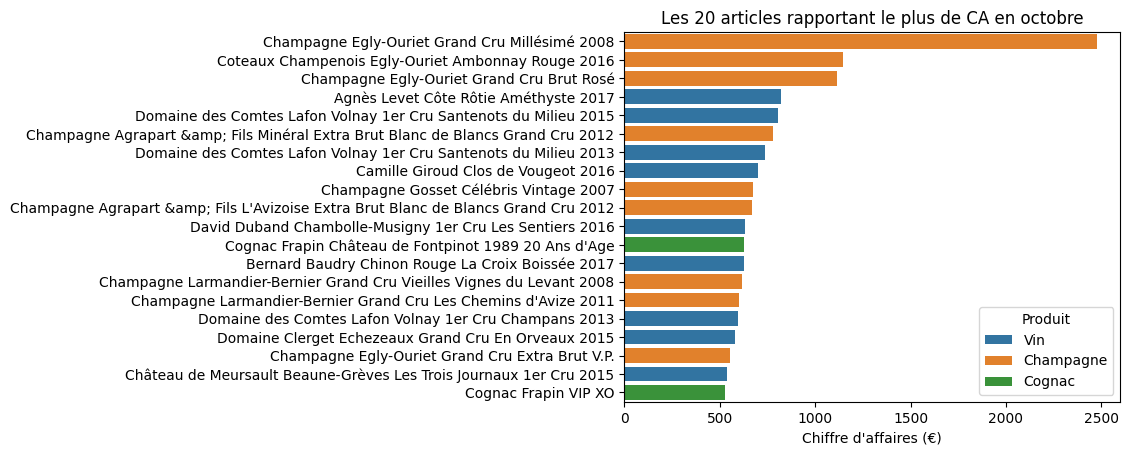

In [66]:
###############################
# Palmarès des articles en CA #
###############################

#Effectuer le tri dans l'ordre décroissant du CA du dataset df_analyse_ca
df_analyse_ca.sort_values(by='ca', ascending=False, inplace=True)

#Réinitialiser l'index du dataset par un reset_index
df_analyse_ca.reset_index(drop=True, inplace=True)

#Afficher les 20 premiers articles en CA
df_analyse_ca.head(20)

#Graphique en barre des 20 premiers articles
sns.barplot(data=df_analyse_ca.head(20), x='ca', y='post_title', hue='product_type', hue_order=['Vin','Champagne', 'Cognac'])
plt.xlabel('Chiffre d\'affaires (€)')
plt.ylabel('')
plt.legend(title='Produit')
plt.title('Les 20 articles rapportant le plus de CA en octobre')
plt.show()

In [67]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part du CA de la ligne dans le dataset
df_analyse_ca['part_ca_total'] = df_analyse_ca['ca'] / df_analyse_ca['ca'].sum()

#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_analyse_ca['cumul_part_ca_total'] = df_analyse_ca['part_ca_total'].cumsum()

#Identification des produits représentant les 80% en quantités vendues en créant une colonne 'priority_ca'
df_analyse_ca['priority_ca'] = np.where(df_analyse_ca['cumul_part_ca_total'] <= 0.8, '1', '0')

#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% du CA
df_ca_80=df_analyse_ca.loc[df_analyse_ca['cumul_part_ca_total'] <= 0.8]

#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
proportion_ca_pareto=df_ca_80.shape[0] / df_analyse_ca.shape[0]*100
print('{}% des articles représentent 80% du CA en octobre.'.format(round(proportion_ca_pareto,2)))

57.58% des articles représentent 80% du CA en octobre.


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.2 - Analyse des ventes en quantité</h3>
</div>

In [68]:
#####################################
# Palmarès des articles en quantité #
#####################################

df_analyse_quantity=df_merge_final.copy()

#Effectuer le tri dans l'ordre décroissant de quantités vendues du dataset df_analyse_quantity
df_analyse_quantity.sort_values(by='total_sales', ascending=False, inplace=True)

#Réinitialiser l'index du dataset par un reset_index
df_analyse_quantity.reset_index(drop=True, inplace=True)

#Afficher les 20 premiers articles en quantité
df_analyse_quantity.head(20)

,product_id,price,stock_quantity,purchase_price,id_web,total_sales,product_type,post_title
0,4867,9.9,121,4.86,16148,36.0,Vin,Château De La Selve IGP Coteaux de l'Ardèche M...
1,4203,9.9,74,5.01,15415,27.0,Vin,Mas Laval IGP Pays d'Hérault Les Pampres Blanc...
2,4275,14.9,62,7.78,14864,24.0,Vin,I Fabbri Chianti Classico Lamole 2017
3,4647,28.5,45,14.14,16525,22.0,Vin,Bernard Baudry Chinon Rouge La Croix Boissée 2017
4,4726,12.7,0,6.82,14950,22.0,Vin,François Baur Pinot Noir Schlittweg 2017
5,6129,5.2,68,2.74,14570,20.0,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Bl...
6,5826,41.2,34,21.71,15325,20.0,Vin,Agnès Levet Côte Rôtie Améthyste 2017
7,4220,11.6,48,5.75,15758,18.0,Vin,Xavier Frissant Touraine Amboise Chenin Les Pi...
8,6569,29.0,58,15.28,15705,17.0,Vin,Decelle-Villa Chorey-Lès-Beaune 2016
9,5803,17.1,47,9.19,13572,17.0,Vin,Château Tour Haut-Caussan Médoc 2015


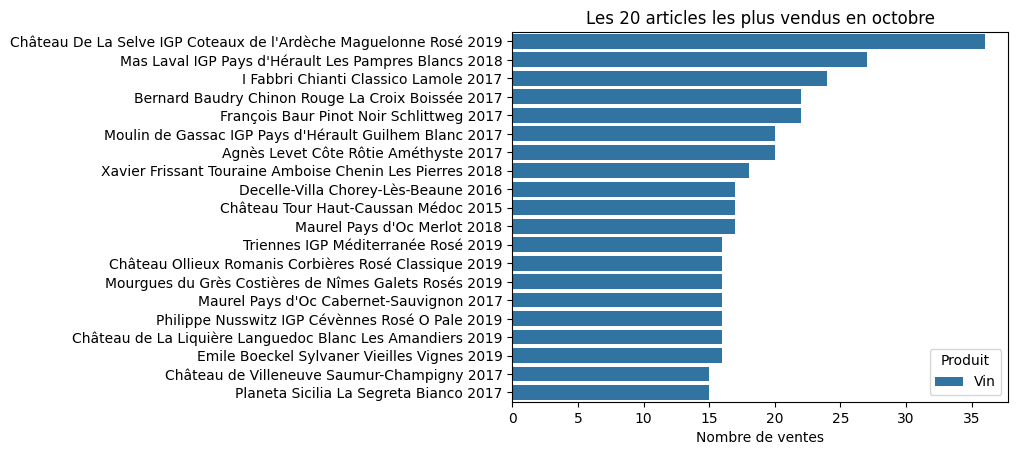

In [69]:
#Graphique en barre des 20 premiers articles
sns.barplot(data=df_analyse_quantity.head(20), x='total_sales', y='post_title', hue='product_type')
sns.color_palette(['red', 'green', 'blue', 'orange'])
plt.xlabel('Nombre de ventes')
plt.ylabel('')
plt.legend(title='Produit')
plt.title('Les 20 articles les plus vendus en octobre')
plt.show()

In [70]:
#############################
# Calculer le 20 / 80 en quantité #
#############################

#Créer une colonne calculant la part en quantité de la ligne dans le dataset
df_analyse_quantity['part_quantity_total'] = df_analyse_quantity['total_sales'] / df_analyse_quantity['total_sales'].sum()

#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_analyse_quantity['cumul_part_quantity_total'] = df_analyse_quantity['part_quantity_total'].cumsum()

#Identification des produits représentant les 80% en quantités vendues en créant une colonne 'priority_quantity'
df_analyse_quantity['priority_quantity'] = np.where(df_analyse_quantity['cumul_part_quantity_total'] <= 0.8, '1', '0')

#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% des ventes en quantité
df_analyse_quantity_80=df_analyse_quantity.loc[df_analyse_quantity['cumul_part_quantity_total'] <= 0.8]

#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
proportion_quantity_pareto=df_analyse_quantity_80.shape[0] / df_analyse_quantity.shape[0]*100
print('{}% des articles représentent 80% des quantités vendues en octobre.'.format(round(proportion_quantity_pareto,2)))

57.45% des articles représentent 80% des quantités vendues en octobre.


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.3 - Analyse des stocks</h3>
</div>

In [71]:
######################################
# Calculer le nombre de mois de stock #
######################################
df_analyse_stock=df_merge_final.copy()

#Création de la colonne mois de stock
df_analyse_stock['month_stock'] = df_analyse_stock['stock_quantity']/df_analyse_stock['total_sales']

#Remplacement des "inf" par 0
df_analyse_stock.replace([np.inf, -np.inf], 0, inplace=True)

#Effectuer le tri dans l'ordre décroissant du nombre de mois de stock dans le dataset df_analyse_stock
df_analyse_stock.sort_values(by='month_stock', ascending=False, inplace=True)

#Réinitialiser l'index du dataset par un reset_index
df_analyse_stock.reset_index(drop=True, inplace=True)

#Afficher les 20 premiers articles en quantité
df_analyse_stock.head(20)

,product_id,price,stock_quantity,purchase_price,id_web,total_sales,product_type,post_title,month_stock
0,4142,53.0,125,32.15,11641,4.0,Champagne,Champagne Gosset Grand Millésime 2006,31.250000
1,6126,135.0,138,80.33,14923,5.0,Champagne,Champagne Gosset Célébris Vintage 2007,27.600000
2,4356,51.6,81,31.00,12585,3.0,Champagne,Champagne Egly-Ouriet Premier Cru Les Vignes d...,27.000000
3,4348,59.0,125,34.76,12586,5.0,Champagne,Champagne Egly-Ouriet Grand Cru Brut Tradition,25.000000
4,4148,37.5,71,21.88,1364,3.0,Champagne,Champagne Mailly Grand Cru Brut Rosé,23.666667
5,4144,49.0,91,27.73,1662,4.0,Champagne,Champagne Gosset Grand Rosé,22.750000
6,5025,112.0,136,68.60,13914,6.0,Champagne,Champagne Agrapart &amp; Fils L'Avizoise Extra...,22.666667
7,4350,79.5,145,47.30,12588,7.0,Champagne,Champagne Egly-Ouriet Grand Cru Extra Brut V.P.,20.714286
8,4150,59.0,123,35.45,1366,6.0,Champagne,Champagne Mailly Grand Cru Intemporelle 2010,20.500000
9,4334,49.0,142,30.01,7818,7.0,Champagne,Champagne Gosset Grand Blanc de Blancs,20.285714


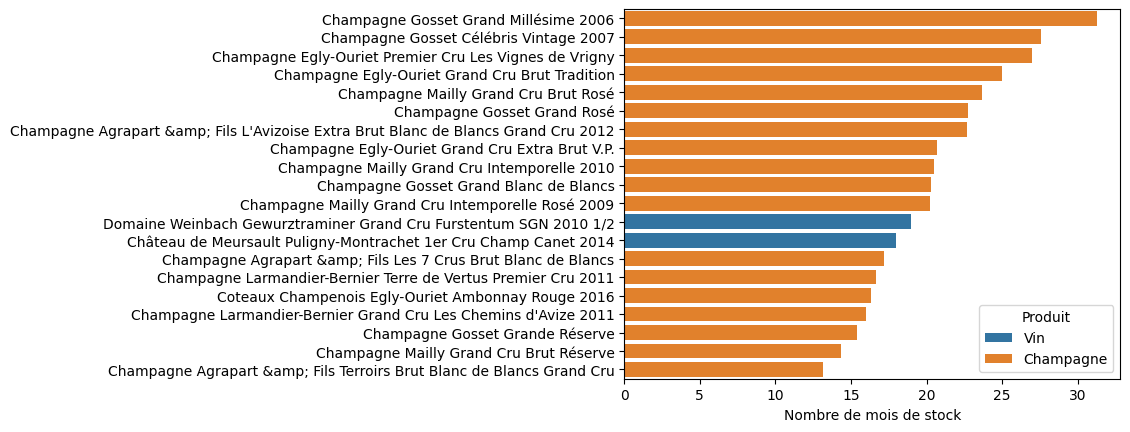

In [72]:
#Graphique en barre du flop 20 des produits qui ont le plus de mois de stock
sns.barplot(data=df_analyse_stock.head(20), x='month_stock', y='post_title', hue='product_type', hue_order=['Vin','Champagne'])
plt.xlabel('Nombre de mois de stock')
plt.ylabel('')
plt.legend(title='Produit')
plt.show()

In [73]:
####################################
# Valorisation des stocks en euros #
####################################

#Création de la colonne Valorisation des stocks en euros
df_analyse_stock['stock_value'] = df_analyse_stock['stock_quantity'] * df_analyse_stock['purchase_price']

#Calculer la somme de la colonne "Valorisation_stock"
print('Valeur du stock en octobre : {} €'.format(round(df_analyse_stock['stock_value'].sum(),2)))

Valeur du stock en octobre : 284198.98 €


In [74]:
##############################################
# Valorisation du nombre de produits en stock #
##############################################

#Calculer la somme de la colonne stock quantity
print('Nombre de produits en stock en octobre : {} unités'.format(round(df_analyse_stock['stock_quantity'].sum(),2)))

Nombre de produits en stock en octobre : 17461 unités


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.4 - Analyse du taux de marge</h3>
</div>

In [75]:
############################
# Analyse du taux de marge #
############################

df_analyse_marge=df_merge_final.copy()

#Création de la colonne Prix HT
df_analyse_marge['price_ht'] = df_analyse_marge['price'] / 1.2

#Création de la colonne Taux de marge
df_analyse_marge['taux_marge'] = (df_analyse_marge['price_ht'] - df_analyse_marge['purchase_price']) / df_analyse_marge['purchase_price']*100

#Afficher le taux de marge minimum
taux_marge_min = df_analyse_marge['taux_marge'].min()
prix_vente_min = df_analyse_marge.loc[df_analyse_marge['taux_marge'] == taux_marge_min, 'price'].iloc[0]
print('Le taux de marge minimum est de {}% pour un prix de vente de {}€'.format(round(taux_marge_min, 2), round(prix_vente_min, 2)))

#Afficher le taux de marge maximum
taux_marge_max = df_analyse_marge['taux_marge'].max()
prix_vente_max = df_analyse_marge.loc[df_analyse_marge['taux_marge'] == taux_marge_max, 'price'].iloc[0]
print('Le taux de marge maximum est de {}% pour un prix de vente de {}€'.format(round(taux_marge_max, 2), round(prix_vente_max, 2)))

#Afficher le taux de marge moyen
taux_marge_moyen = df_analyse_marge['taux_marge'].mean()
print('Le taux de marge moyen est de {}%'.format(round(taux_marge_moyen, 2)))

Le taux de marge minimum est de 29.5% pour un prix de vente de 13.1€
Le taux de marge maximum est de 91.41% pour un prix de vente de 62.5€
Le taux de marge moyen est de 61.25%


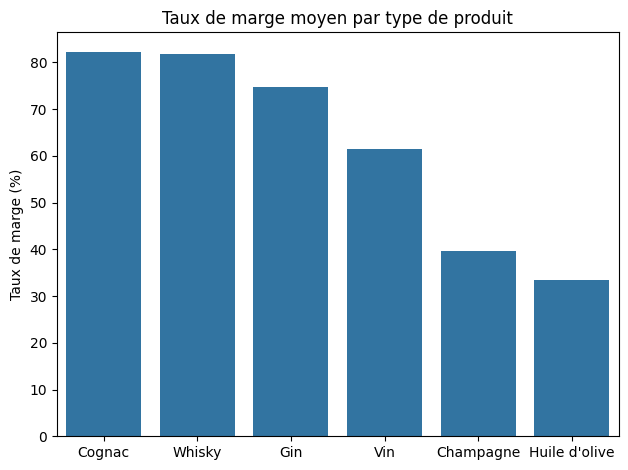

In [76]:
#Création d'un dataframe avec le taux de marge moyen par type de produit
df_analyse_marge_produit = df_analyse_marge.groupby('product_type')['taux_marge'].mean().reset_index()
df_analyse_marge_produit.sort_values(by='taux_marge', ascending=False, inplace=True)

#Affichage dans un graphique du taux de marge par type de produit
sns.barplot(data=df_analyse_marge_produit, x='product_type', y='taux_marge')
plt.xlabel('')
plt.ylabel('Taux de marge (%)')
plt.title('Taux de marge moyen par type de produit')
plt.tight_layout()
plt.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.5 - Analyse des corrélations entre les variables stock, sales et price</h3>
</div>

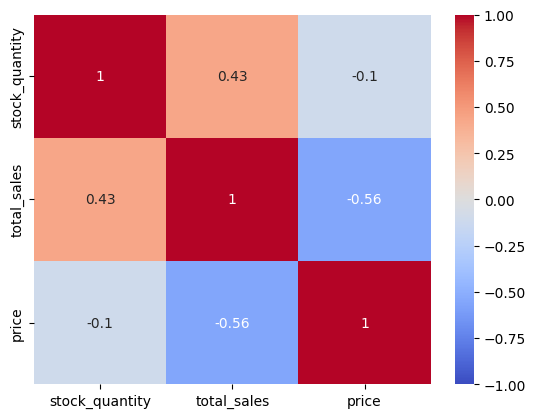

In [77]:
############################
# Analyse des corrélations #
############################

#Création d'une heatmap de corrélation avec les variables stock, sales et price
sns.heatmap(df_merge_final[['stock_quantity', 'total_sales', 'price']].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

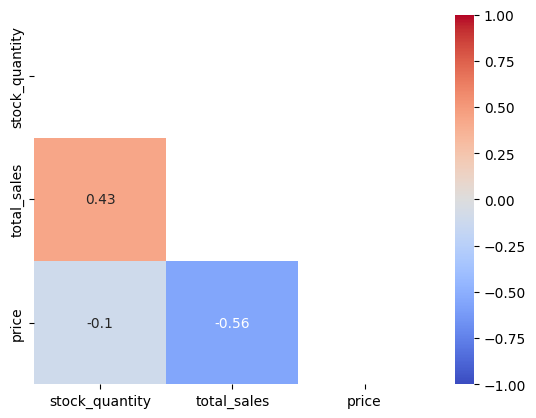

In [78]:
#On peut également créer un mask pour n'afficher qu'une demi heatmap
mask = np.triu(np.ones_like(df_merge_final[['stock_quantity', 'total_sales', 'price']].corr()))
sns.heatmap(df_merge_final[['stock_quantity', 'total_sales', 'price']].corr(), annot=True, cmap='coolwarm', mask=mask, vmin=-1, vmax=1)
plt.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.6 - Mise à disposition de la nouvelle table sur un fichier Excel</h3>
</div>

In [79]:
#Selection des colonnes pertinentes
df_ca=df_analyse_ca[['product_id', 'ca', 'part_ca_total', 'priority_ca']]
df_quantity=df_analyse_quantity[['product_id', 'part_quantity_total', 'priority_quantity']]
df_stock=df_analyse_stock[['product_id', 'month_stock', 'stock_value']]
df_marge=df_analyse_marge[['product_id', 'price_ht', 'taux_marge']]

In [80]:
#Joindre les colonnes pertinentes dans une ultime dataframe
df_final=pd.merge(df_merge_final, df_ca, on='product_id', how='left')
df_final=pd.merge(df_final, df_quantity, on='product_id', how='left')
df_final=pd.merge(df_final, df_stock, on='product_id', how='left')
df_final=pd.merge(df_final, df_marge, on='product_id', how='left')
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 745 entries, 0 to 744
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           745 non-null    int64  
 1   price                745 non-null    float64
 2   stock_quantity       745 non-null    int64  
 3   purchase_price       745 non-null    float64
 4   id_web               686 non-null    object 
 5   total_sales          684 non-null    float64
 6   product_type         684 non-null    object 
 7   post_title           684 non-null    object 
 8   ca                   684 non-null    float64
 9   part_ca_total        684 non-null    float64
 10  priority_ca          745 non-null    object 
 11  part_quantity_total  684 non-null    float64
 12  priority_quantity    745 non-null    object 
 13  month_stock          684 non-null    float64
 14  stock_value          745 non-null    float64
 15  price_ht             745 non-null    flo

In [81]:
#Afficher les premières lignes de ce nouveau dataframe
df_final.head(5)

,product_id,price,stock_quantity,purchase_price,id_web,total_sales,product_type,post_title,ca,part_ca_total,priority_ca,part_quantity_total,priority_quantity,month_stock,stock_value,price_ht,taux_marge
0,3847,24.2,16,12.88,15298,6.0,Vin,Pierre Jean Villa Saint-Joseph Préface 2018,145.2,0.001021,0,0.001052,0,2.666667,206.08,20.166667,56.573499
1,3849,34.3,10,17.54,15296,9.0,Vin,Pierre Jean Villa Saint-Joseph Rouge Tildé 2017,308.7,0.002170,1,0.001578,1,1.111111,175.40,28.583333,62.960851
2,4032,14.1,26,6.92,19814,12.0,Vin,Pierre Jean Villa IGP Collines Rhodaniennes Ga...,169.2,0.001189,1,0.002104,1,2.166667,179.92,11.750000,69.797688
3,4041,32.7,12,17.57,14975,6.0,Vin,Pierre Gaillard Condrieu 2018,196.2,0.001379,1,0.001052,0,2.000000,210.84,27.250000,55.093910
4,4042,31.2,15,15.48,16042,8.0,Vin,Pierre Gaillard Cornas 2017,249.6,0.001755,1,0.001403,1,1.875000,232.20,26.000000,67.958656


In [82]:
#Mettre le dataset df_merge sur un fichier Excel
df_final.to_excel('drive/MyDrive/Colab Notebooks/df_final.xlsx', index=False)